In [45]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
from scipy import  stats
from statsmodels.graphics.tsaplots import plot_acf


 I selected SPY ETF data because the fund tracks S&P 500 index, making it a reliable proxy for overall market behavior

In [ ]:
data = yf.download("SPY", start = "2000-01-01", end  ="2019-12-31",auto_adjust=True)

save_path = r"C:\Users\engin\Engin Py\regime_switching\spy_data_2000-2019.csv"
data.to_csv(save_path)
print(f"Success, your file saved precisely to {save_path}")


[*********************100%***********************]  1 of 1 completed

Success, your file saved precisely to C:\Users\engin\Engin Py\regime_switching\spy_data_2000-2019.csv


In [7]:
spy_data = pd.read_csv("spy_data_2000-2019.csv")
print(spy_data.head(5))
print("-------------------------------------------------------------------------------")
print()
print(spy_data.tail(5))



        Price              Close               High                Low  \
0      Ticker                SPY                SPY                SPY   
1        Date                NaN                NaN                NaN   
2  2000-01-03  91.13272857666016   92.8950718452247  90.15364898301318   
3  2000-01-04  87.56889343261719  90.27115356090458  87.50035784965338   
4  2000-01-05  87.72552490234375  88.68502283096313  86.00234494890485   

                Open    Volume  
0                SPY       SPY  
1                NaN       NaN  
2   92.8950718452247   8164300  
3  89.93826644365178   8089800  
4  87.68636172158378  12177900  
-------------------------------------------------------------------------------

           Price               Close                High                 Low  \
5027  2019-12-23   292.7983093261719  293.19025605431125  292.65246286090326   
5028  2019-12-24   292.8073425292969  293.07166308676193   292.5065255951328   
5029  2019-12-26   294.3659362792969

Analyzing daily data can be exhausting because of the noise so i downloaded another csv with 1-week interval.

In [8]:
data_week = yf.download("SPY", start = "2000-01-01", end = "2019-12-31", auto_adjust = True, interval = "1wk")
save_path_week = r"C:\Users\engin\Engin Py\regime_switching\spy_data_2000-2019_1w.csv"
data_week.to_csv(save_path_week)
print(f"Success, your file saved precisely to {save_path_week}")

[*********************100%***********************]  1 of 1 completed

Success, your file saved precisely to C:\Users\engin\Engin Py\regime_switching\spy_data_2000-2019_1w.csv


In [ ]:
spy_weekly_data = pd.read_csv(
    "spy_data_2000-2019_1w.csv", 
    skiprows=3,  
    names=["Date", "Close", "High", "Low", "Open", "Volume"], 
    parse_dates=["Date"], 
    index_col="Date"
)
spy_weekly_data["Log_Return"] = np.log(spy_weekly_data["Close"] / spy_weekly_data["Close"].shift(1))
spy_weekly_data = spy_weekly_data
print(spy_weekly_data.head())


                Close       High        Low       Open    Volume  Log_Return
Date                                                                        
2000-01-08  92.092232  92.405537  89.527043  91.641855  32748700    0.008327
2000-01-15  90.506119  92.111809  90.114487  91.073985  24691300   -0.017373
2000-01-22  85.140823  91.387356  84.925426  91.269866  45836400   -0.061111
2000-01-29  89.350853  90.232025  84.592524  85.101645  38317400    0.048264
2000-02-05  86.903114  90.584454  86.491901  89.331232  35834100   -0.027777


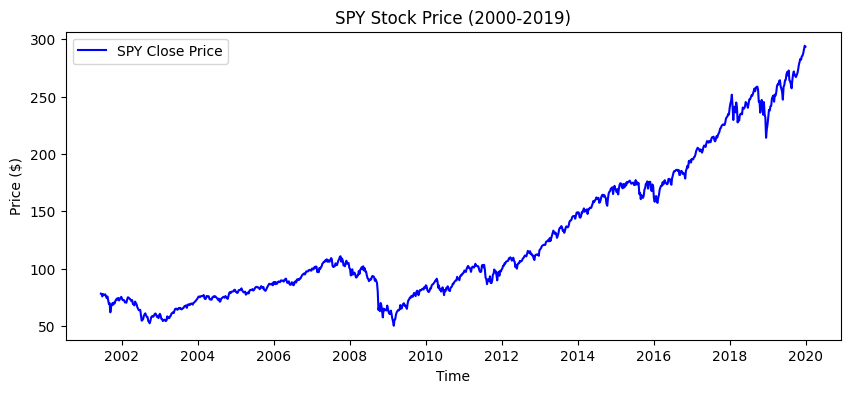

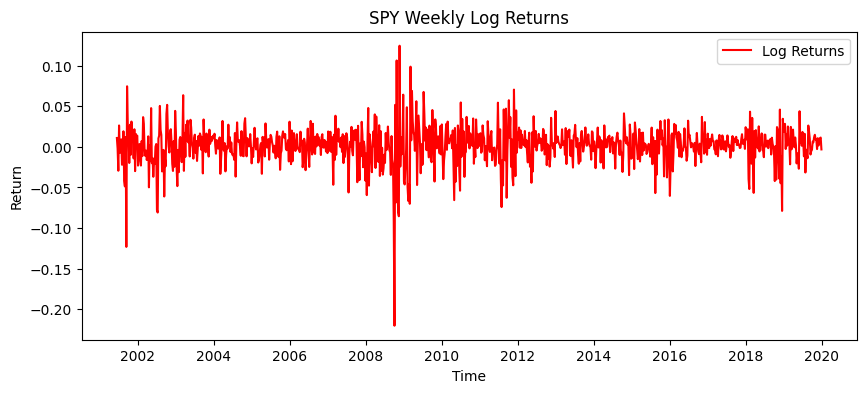

In [40]:
plt.figure(figsize=(10, 4)) 
plt.plot(spy_weekly_data.index, spy_weekly_data["Close"], label="SPY Close Price", color="blue")
plt.title("SPY Stock Price (2000-2019)")
plt.xlabel("Time")
plt.ylabel("Price ($)")
plt.legend()
plt.show() 

plt.figure(figsize=(10, 4)) 
plt.plot(spy_weekly_data.index, spy_weekly_data["Log_Return"], color="red", label="Log Returns")
plt.title("SPY Weekly Log Returns")
plt.xlabel("Time")
plt.ylabel("Return")
plt.legend()
plt.show() 

In [39]:
window_size = 26

spy_weekly_data["Rolling_Weekly_Volatility"] = spy_weekly_data["Log_Return"].rolling(window = window_size).std()
spy_weekly_data["Annual_Rolling_Volatility"] = spy_weekly_data["Rolling_Weekly_Volatility"] * np.sqrt(52)
spy_weekly_data = spy_weekly_data.dropna()
max_vol = spy_weekly_data["Annual_Rolling_Volatility"].max()
max_vol_date = spy_weekly_data["Annual_Rolling_Volatility"].idxmax()
print(f"Maximum annual volatility:{max_vol}, Maximum annual volatility date: {max_vol_date}")
print(spy_weekly_data.head())


Maximum annual volatility:0.5414845288947547, Maximum annual volatility date: 2009-03-21 00:00:00
                Close       High        Low       Open    Volume  Log_Return  \
Date                                                                           
2001-06-16  78.220016  79.149615  76.972062  77.455965  52358900    0.011013   
2001-06-23  78.060829  78.958595  76.768306  78.493793  46611200   -0.002037   
2001-06-30  75.800514  79.155982  75.800514  78.188183  29009100   -0.029383   
2001-07-07  77.831612  77.882550  74.552546  76.080655  54735200    0.026443   
2001-07-14  77.258575  78.302787  76.297145  77.532362  38883100   -0.007390   

            Rolling_Weekly_Volatility  Annual_Rolling_Volatility  
Date                                                              
2001-06-16                   0.026962                   0.194426  
2001-06-23                   0.026949                   0.194331  
2001-06-30                   0.027356                   0.197267  
2001-0

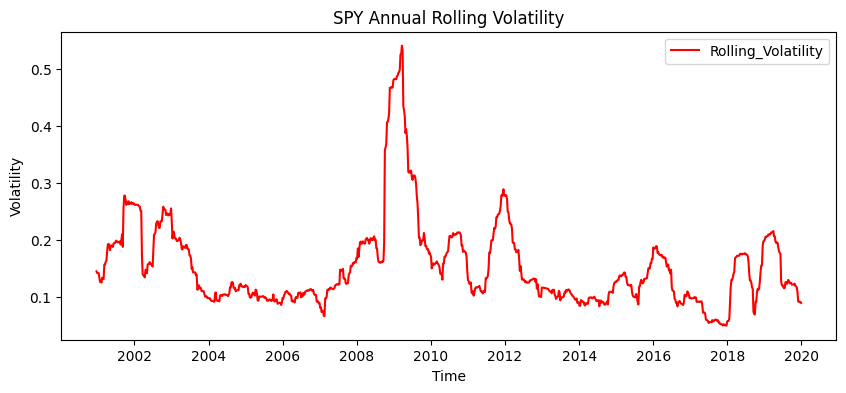

In [38]:
plt.figure(figsize=(10, 4)) 
plt.plot(spy_weekly_data.index, spy_weekly_data["Annual_Rolling_Volatility"], color="red", label="Rolling_Volatility")
plt.title("SPY Annual Rolling Volatility")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()
plt.show() 

C:\Users\engin\AppData\Local\Temp\ipykernel_12128\1908421608.py:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(x, p, "k", linewidth=2, color="red", label="Gaussian Distribution")


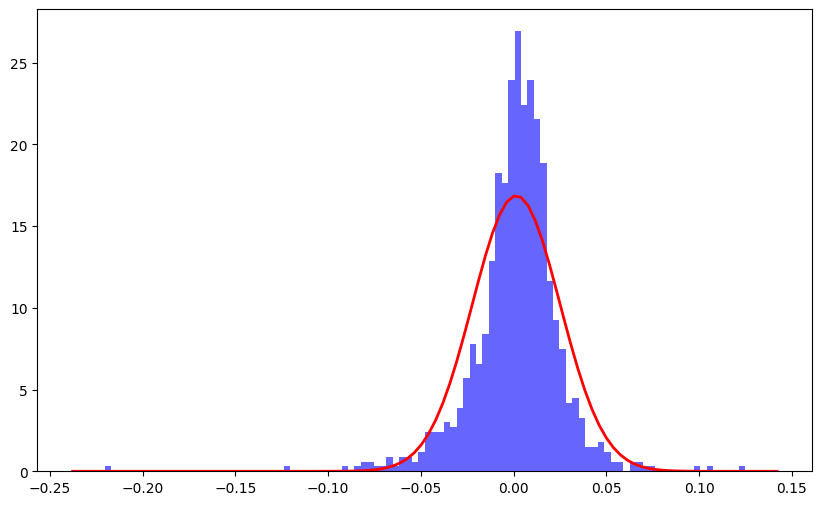

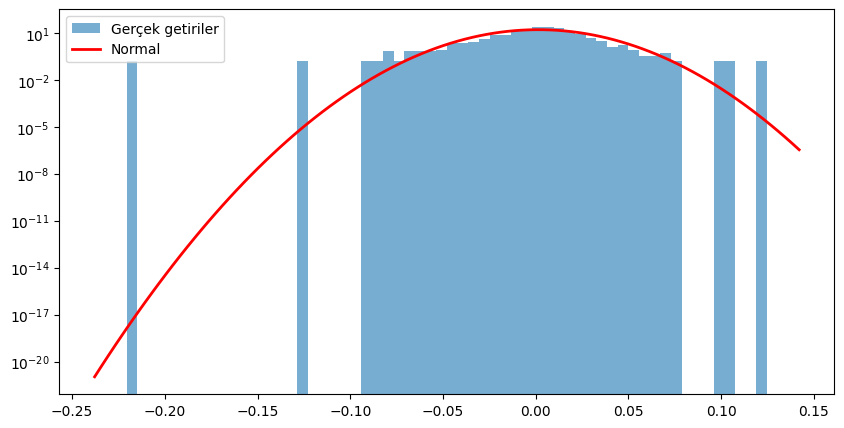

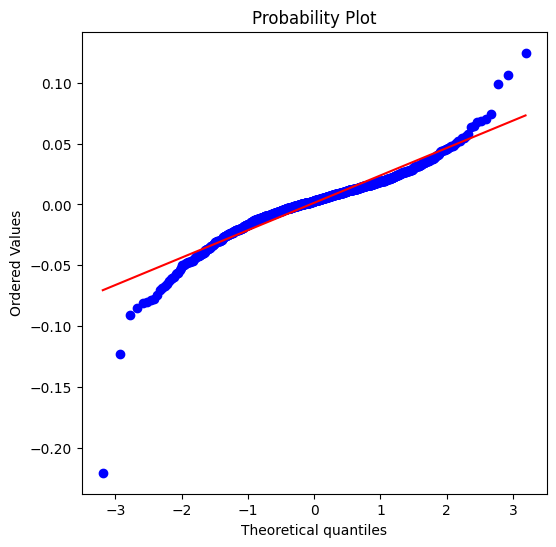

Excess Kurtosis Value: 10.75


In [48]:
log_returns = spy_weekly_data["Log_Return"].dropna()

mu = log_returns.mean()
std = log_returns.std()

plt.figure(figsize=(10,6))
plt.hist(log_returns, bins=100, density=True, alpha=0.6, color='blue', label='Gerçek Getiriler (Histogram)')

xmin, xmax = plt.xlim()

x = np.linspace(xmin, xmax, 100)

p = stats.norm.pdf(x, mu, std)

plt.plot(x, p, "k", linewidth=2, color="red", label="Gaussian Distribution")

fig, ax = plt.subplots(figsize=(10,5))
ax.hist(log_returns, bins=60, density=True, alpha=0.6, label="Gerçek getiriler")
ax.plot(x, stats.norm.pdf(x, mu, std), color="red", lw=2, label="Normal")
ax.set_yscale("log")   
ax.legend(); plt.show()


fig, ax = plt.subplots(figsize=(6,6))
stats.probplot(log_returns, dist="norm", plot=ax)
plt.show()


kurtosis_degeri = log_returns.kurtosis()
print(f"Excess Kurtosis Value: {kurtosis_degeri:.2f}")

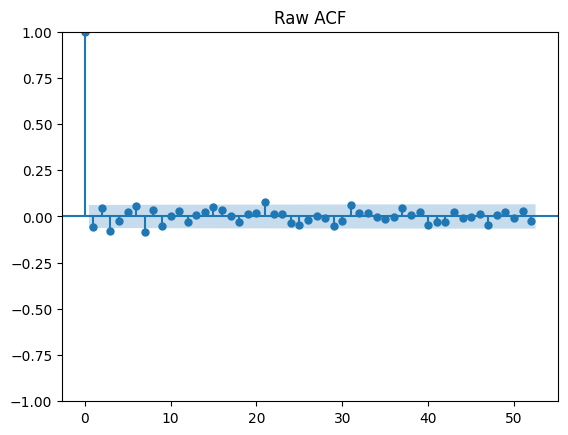

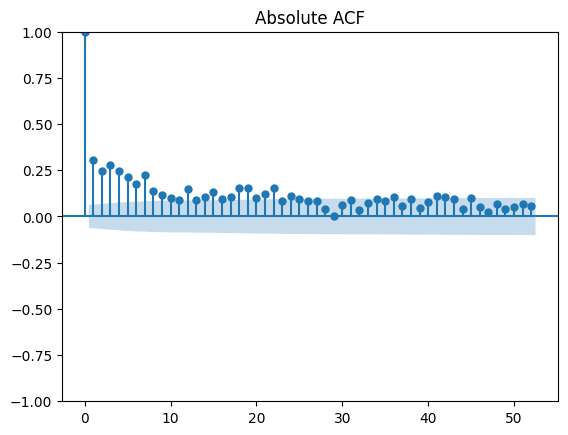

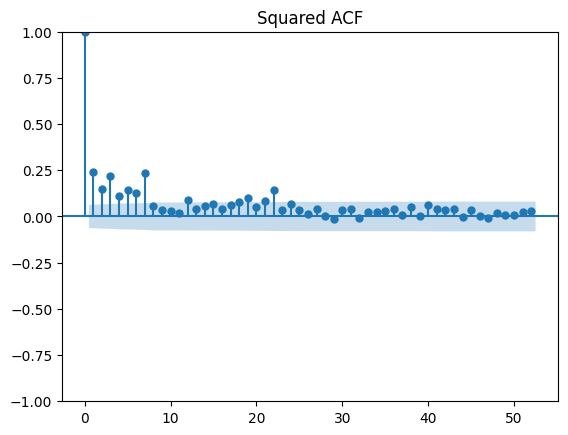

In [41]:
plot_acf(log_returns,lags=52,title="Raw ACF")
plt.show()

absolute_log_returns = pd.Series.abs(log_returns)
plot_acf(absolute_log_returns,lags=52,title = "Absolute ACF")
plt.show()

squared_log_returns = log_returns **2
plot_acf(squared_log_returns, lags=52, title = "Squared ACF")
plt.show()




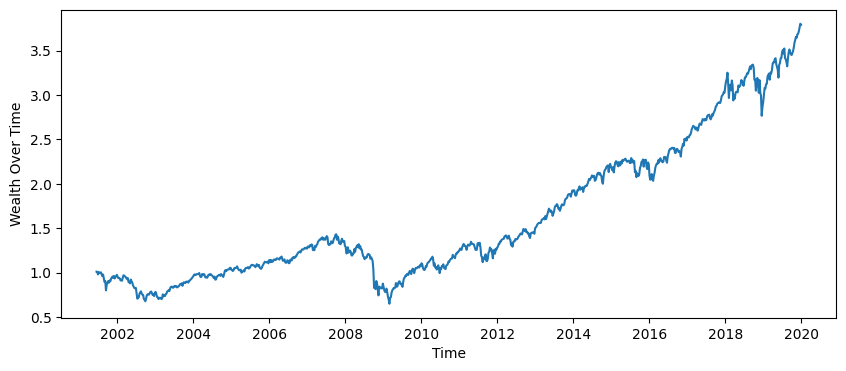

Peak Value of SPY: 3.8040409618783135
Date of Peak Value of SPY: 2019-12-21 00:00:00


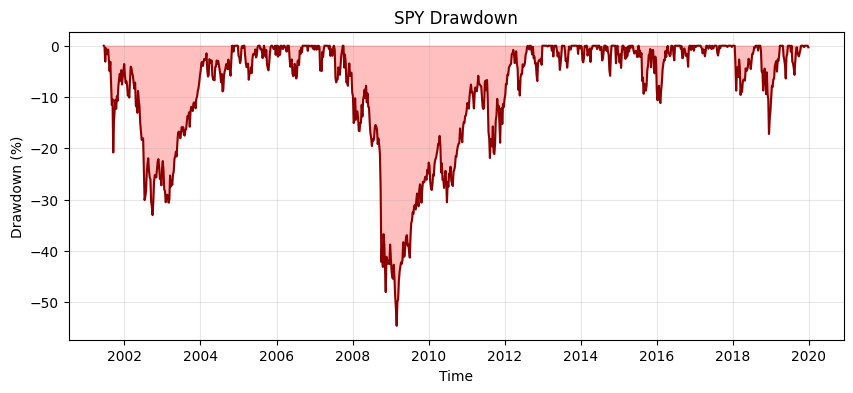

Maximum Drawdown: -54.61%
Maximum Drawdown Date: 2009-02-28 00:00:00


In [59]:
wealth_index = np.exp(log_returns.cumsum())

peak = wealth_index.cummax()          
drawdown = wealth_index / peak - 1
max_dd = drawdown.min()

plt.figure(figsize=(10,4))
plt.plot(wealth_index.index, wealth_index, label = "Wealth Index")
plt.ylabel("Wealth Over Time")
plt.xlabel("Time")
plt.show()
print(f"Peak Value of SPY: {wealth_index.max()}")
print(f"Date of Peak Value of SPY: {wealth_index.idxmax()}")



wealth_index = np.exp(log_returns.cumsum())

peak = wealth_index.cummax()
drawdown = wealth_index / peak - 1
max_dd = drawdown.min()

plt.figure(figsize=(10, 4))
plt.plot(drawdown.index, drawdown * 100, color="darkred")
plt.fill_between(
    drawdown.index,
    drawdown * 100,
    0,
    color="red",
    alpha=0.25
)

plt.title("SPY Drawdown")
plt.xlabel("Time")
plt.ylabel("Drawdown (%)")
plt.grid(alpha=0.3)
plt.show()

print(f"Maximum Drawdown: {max_dd:.2%}")
print(f"Maximum Drawdown Date: {drawdown.idxmin()}")